# Predicting Bike Sharing Demand Using Machine Learning and Temporal Features
**Author:** Thammishetti Venkat Sai Prathap  
**Programme:** MSc Data Science — University of Hertfordshire  

**Dataset:** UCI Bike Sharing Dataset (`hour.csv`) — hourly bike rental counts for 2011–2012  
**Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset)

---
## Project Overview
This notebook predicts hourly bike rental demand using three approaches:
- **Random Forest Regressor** — ensemble tree-based model
- **XGBoost Regressor** — gradient boosting with lag features
- **SARIMAX** — statistical time-series model

Key techniques used: cyclical feature encoding (sin/cos), lag features, time-based train-test splitting.


## 1. Imports

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from xgboost import XGBRegressor
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller


## 2. Load Dataset
The dataset contains **17,379 hourly records** of bike rentals from the Capital Bikeshare system in Washington D.C.  
The target variable is `cnt` — total number of bikes rented per hour (casual + registered users).

In [17]:
Bike = pd.read_csv("hour.csv")

print(f"Shape : {Bike.shape[0]:,} rows × {Bike.shape[1]} columns")
print(f"Date range : {Bike['dteday'].min()} → {Bike['dteday'].max()}")
print()
Bike.head(3)


Shape : 17,379 rows × 17 columns
Date range : 2011-01-01 → 2012-12-31



,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


## 3. Data Exploration


In [18]:
# ── Schema & types ───────────────
print('=== Dataset Info ===')
Bike.info()
print()
print('=== Data Types ===')
print(Bike.dtypes)


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

=== Data Types ===
instant 

In [19]:
# ── Summary statistics ───────────────────
print('=== Dataset columns ===')
print(Bike.columns)
print("=== Descriptive Statistics ===")
Bike.describe().round(3)

=== Dataset columns ===
Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')
=== Descriptive Statistics ===


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000
mean,8690.000,2.502,0.503,6.538,11.547,0.029,3.004,0.683,1.425,0.497,0.476,0.627,0.190,35.676,153.787,189.463
std,5017.029,1.107,0.500,3.439,6.914,0.167,2.006,0.465,0.639,0.193,0.172,0.193,0.122,49.305,151.357,181.388
min,1.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.020,0.000,0.000,0.000,0.000,0.000,1.000
25%,4345.500,2.000,0.000,4.000,6.000,0.000,1.000,0.000,1.000,0.340,0.333,0.480,0.104,4.000,34.000,40.000
50%,8690.000,3.000,1.000,7.000,12.000,0.000,3.000,1.000,1.000,0.500,0.485,0.630,0.194,17.000,115.000,142.000
75%,13034.500,3.000,1.000,10.000,18.000,0.000,5.000,1.000,2.000,0.660,0.621,0.780,0.254,48.000,220.000,281.000
max,17379.000,4.000,1.000,12.000,23.000,1.000,6.000,1.000,4.000,1.000,1.000,1.000,0.851,367.000,886.000,977.000


In [20]:
# ── Data quality checks ──────────────────
print('=== Missing Values ===')
print(Bike.isnull().sum())
print()
print('=== Duplicate Rows ===')
print(Bike.duplicated().sum())

=== Missing Values ===
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

=== Duplicate Rows ===
0


In [21]:
# ── Target variable summary ─────────────
print('=== Target Variable (cnt) Summary ===')
Bike['cnt'].describe()


=== Target Variable (cnt) Summary ===


,cnt
count,17379.000000
mean,189.463088
std,181.387599
min,1.000000
25%,40.000000
50%,142.000000
75%,281.000000
max,977.000000


## 4. Exploratory Data Analysis (EDA)


### 4.1 · Target Variable Distribution
The target cnt is right-skewed — most hours see low-to-moderate demand, with occasional high-demand spikes during peak commute times.

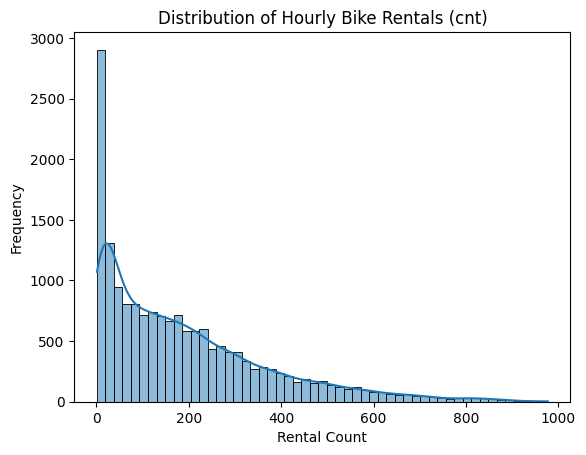

In [22]:
plt.figure()
sns.histplot(Bike['cnt'], kde=True)
plt.title('Distribution of Hourly Bike Rentals (cnt)')
plt.xlabel('Rental Count')
plt.ylabel('Frequency')
plt.show()


### 4.2 Categorical Feature Frequency Counts

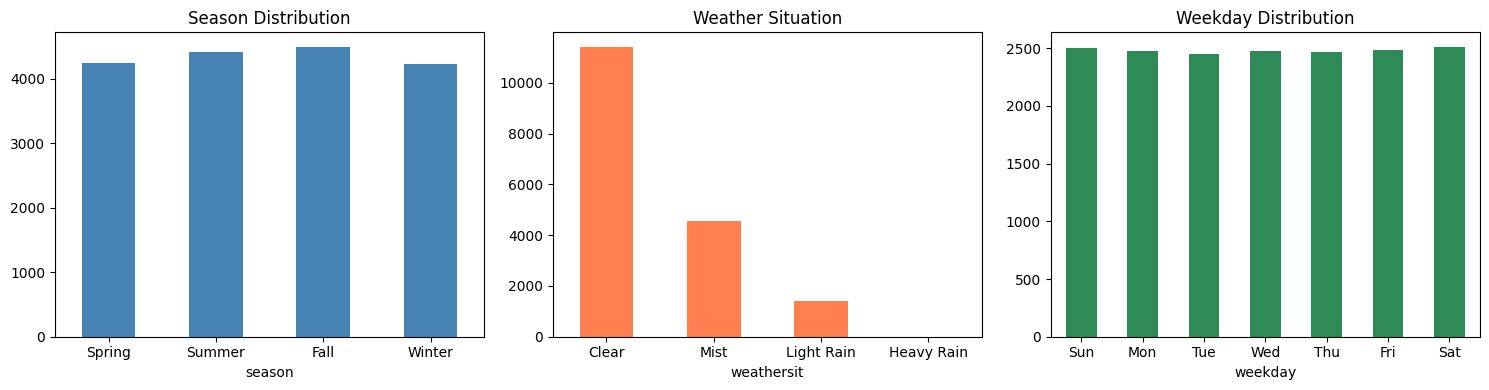

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

Bike['season'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='steelblue', title='Season Distribution')
axes[0].set_xticklabels(['Spring','Summer','Fall','Winter'], rotation=0)

Bike['weathersit'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color='coral', title='Weather Situation')
axes[1].set_xticklabels(['Clear','Mist','Light Rain','Heavy Rain'], rotation=0)

Bike['weekday'].value_counts().sort_index().plot(kind='bar', ax=axes[2],
    color='seagreen', title='Weekday Distribution')
axes[2].set_xticklabels(['Sun','Mon','Tue','Wed','Thu','Fri','Sat'], rotation=0)

plt.tight_layout()
plt.show()


### 4.3 Correlation Heatmap

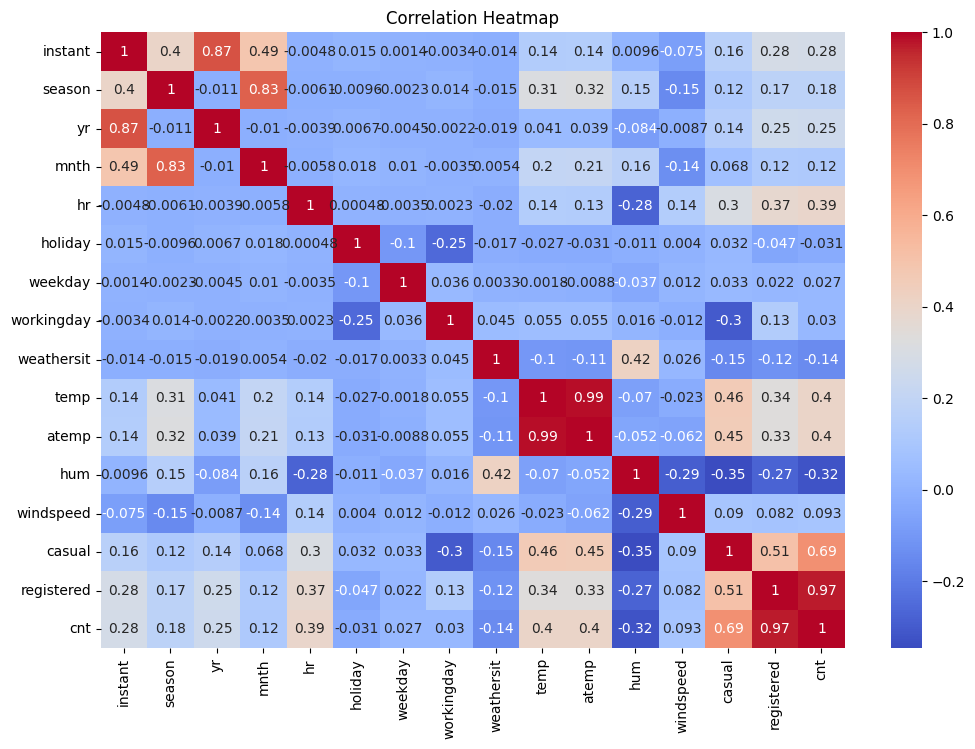

In [24]:
corr = Bike.drop('dteday', axis=1).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


### 4.4 Temperature vs Demand (Scatter Plot)


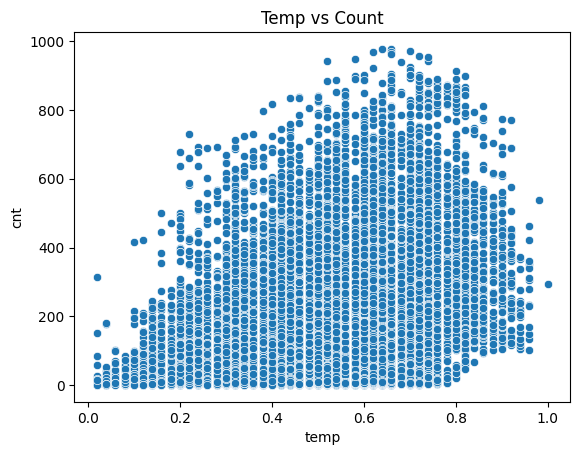

In [25]:
plt.figure()
sns.scatterplot(x='temp', y='cnt', data=Bike)
plt.title("Temp vs Count")
plt.show()


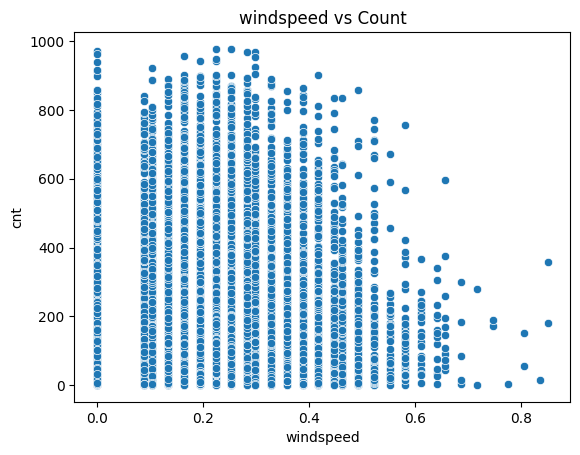

In [26]:
plt.figure()
sns.scatterplot(x='windspeed', y='cnt', data=Bike)
plt.title("windspeed vs Count")
plt.show()

### 4.5 Temporal Patterns

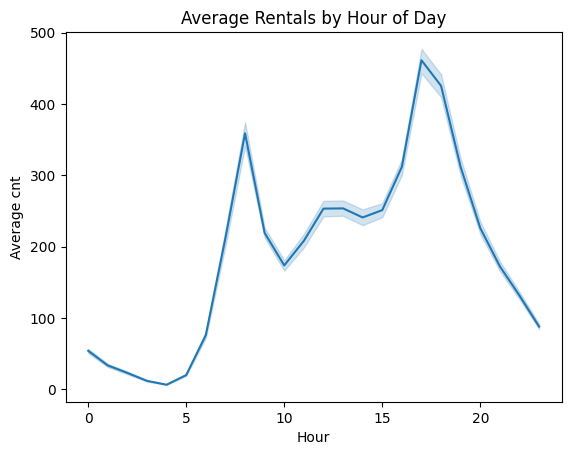

In [27]:
# Rentals by weekday
plt.figure()
sns.lineplot(x="hr", y="cnt", data=Bike, estimator="mean")
plt.title("Average Rentals by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average cnt")
plt.show()

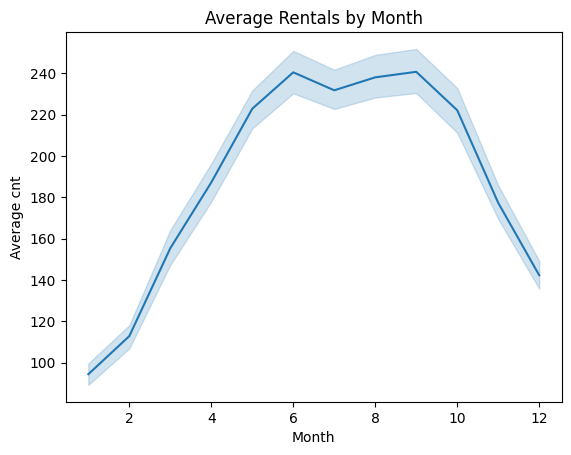

In [28]:

# Rentals by month
plt.figure()
sns.lineplot(x="mnth", y="cnt", data=Bike, estimator="mean")
plt.title("Average Rentals by Month")
plt.xlabel("Month")
plt.ylabel("Average cnt")
plt.show()


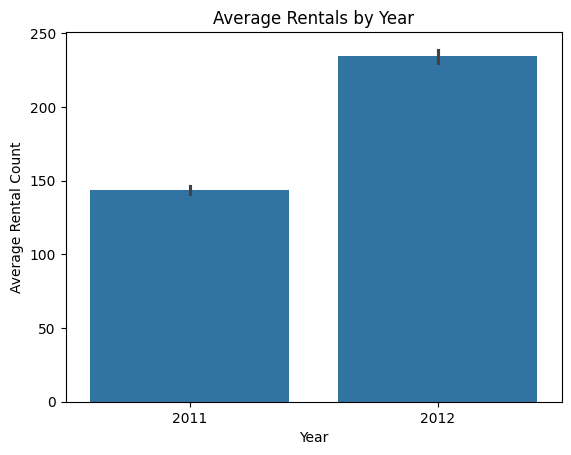

In [29]:
Bike["year_label"] = Bike["yr"].map({0: "2011", 1: "2012"})

plt.figure()
sns.barplot(x="year_label", y="cnt", data=Bike, estimator="mean")
plt.title("Average Rentals by Year")
plt.xlabel("Year")
plt.ylabel("Average Rental Count")
plt.show()


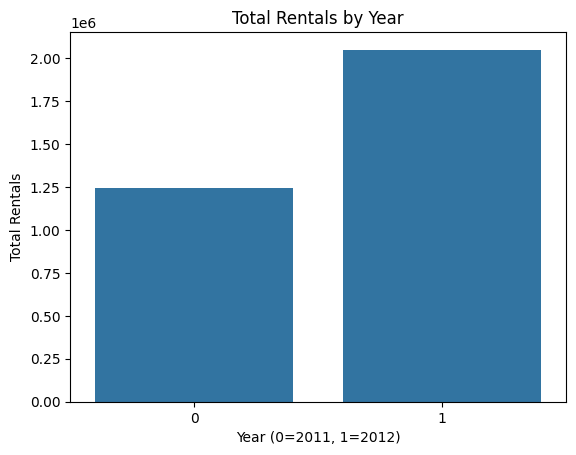

In [30]:
yearly = Bike.groupby("yr")["cnt"].sum().reset_index()

plt.figure()
sns.barplot(x="yr", y="cnt", data=yearly)
plt.title("Total Rentals by Year")
plt.xlabel("Year (0=2011, 1=2012)")
plt.ylabel("Total Rentals")
plt.show()


### 4.6 Boxplot — Feature Spread & Outlier Check

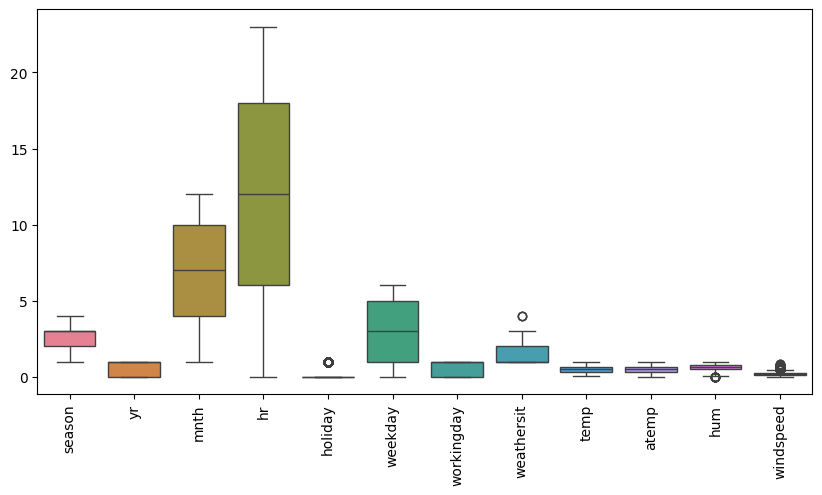

In [31]:
Bike.drop(columns=['instant'], inplace=True)
num_cols = Bike.select_dtypes(include=np.number).columns
plt.figure(figsize=(10,5))
sns.boxplot(data=Bike[['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp','atemp','hum','windspeed']])
plt.xticks(rotation=90)
plt.show()

In [32]:
Q1 = Bike['cnt'].quantile(0.25)
Q3 = Bike['cnt'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_count = ((Bike['cnt'] < lower) | (Bike['cnt'] > upper)).sum()
print(f'Lower bound : {lower:.1f}')
print(f'Upper bound : {upper:.1f}')
print(f'Outlier rows: {outlier_count} ({outlier_count/len(Bike)*100:.1f}% of data)')


Lower bound : -321.5
Upper bound : 642.5
Outlier rows: 505 (2.9% of data)


In [34]:
Bike["dteday"] = pd.to_datetime(Bike["dteday"])
Bike = Bike.sort_values(["dteday", "hr"]).reset_index(drop=True)
print(f"Dataset sorted chronologically. Shape: {Bike.shape}")

Dataset sorted chronologically. Shape: (17379, 17)


## 6. Random Forest — Baseline

**Feature engineering:**
- Cyclical sin/cos encoding for `hr` and `mnth` (preserves circular periodicity)
- One-hot encoding for `season`, `weathersit`, `weekday`
- Chronological 80 / 20 train-test split (no random shuffling)

In [35]:
#  RANDOM FOREST

Bike1 = Bike.copy()

Bike1 = Bike1.drop(columns=["casual", "registered", "instant"], errors="ignore")

Bike1["hr_sin"] = np.sin(2 * np.pi * Bike1["hr"] / 24)
Bike1["hr_cos"] = np.cos(2 * np.pi * Bike1["hr"] / 24)

Bike1["mnth_sin"] = np.sin(2 * np.pi * Bike1["mnth"] / 12)
Bike1["mnth_cos"] = np.cos(2 * np.pi * Bike1["mnth"] / 12)

Bike1 = pd.get_dummies(Bike1, columns=["season", "weathersit", "weekday"], drop_first=True)

# Sort by time
Bike1 = Bike1.sort_values(["dteday", "hr"]).reset_index(drop=True)

# 80-20 split
split_index = int(len(Bike1) * 0.8)

train = Bike1.iloc[:split_index]
test  = Bike1.iloc[split_index:]

X_train = train.drop(columns=["cnt", "dteday"])
y_train = train["cnt"]

X_test = test.drop(columns=["cnt", "dteday"])
y_test = test["cnt"]

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_rf))
mae  = mean_absolute_error(y_test, pred_rf)
r2   = r2_score(y_test, pred_rf)
mape = np.mean(np.abs((y_test - pred_rf) / np.maximum(y_test, 1))) * 100

print("Random Forest Results (80-20 Split)")
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)
print("MAPE:", mape)

Random Forest Results (80-20 Split)
RMSE: 81.32791780186466
MAE : 53.929730581127735
R2  : 0.8639426745720916
MAPE: 35.711469262502874


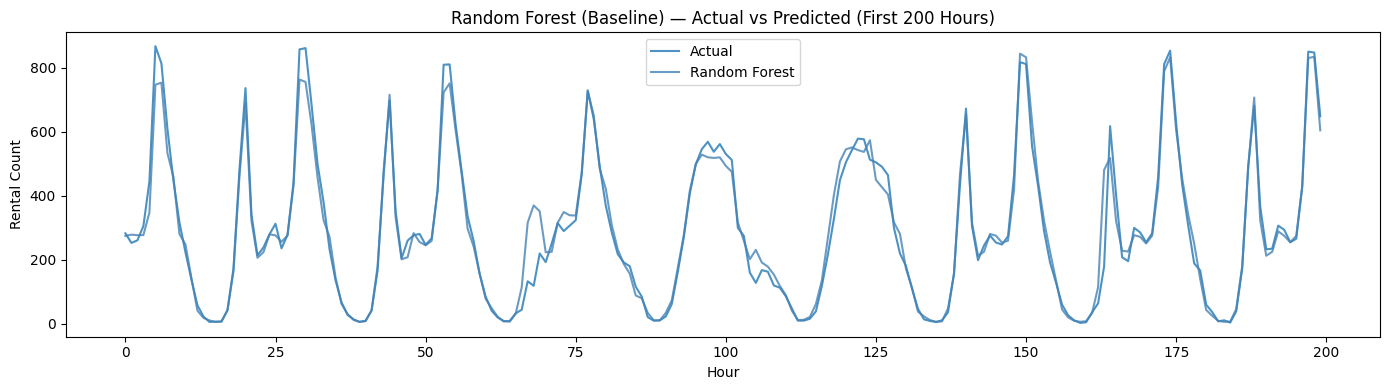

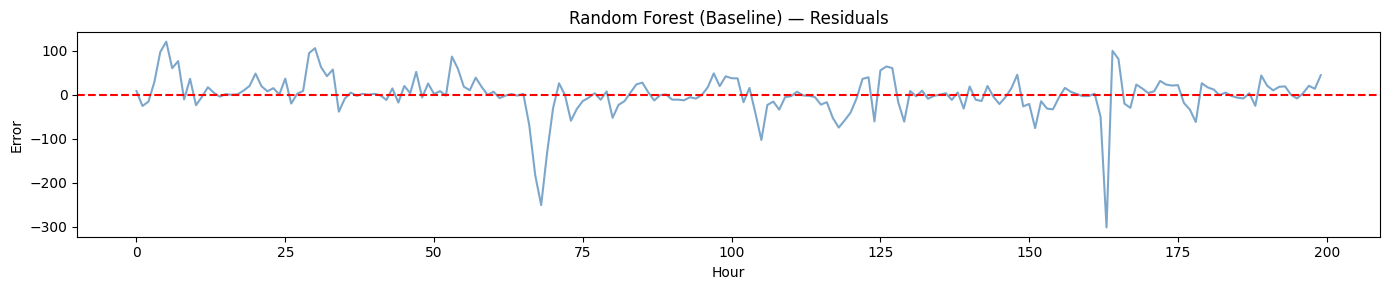

In [36]:
# --- Random Forest Baseline Plot ---
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:200], label="Actual", alpha=0.8)
plt.plot(pred_rf[:200], label="Random Forest", alpha=0.8, color="steelblue")
plt.title("Random Forest (Baseline) — Actual vs Predicted (First 200 Hours)")
plt.xlabel("Hour")
plt.ylabel("Rental Count")
plt.legend()
plt.tight_layout()
plt.show()

# Residuals
residuals_rf = y_test.values - pred_rf
plt.figure(figsize=(14, 3))
plt.plot(residuals_rf[:200], color="steelblue", alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.title("Random Forest (Baseline) — Residuals")
plt.xlabel("Hour")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

## 7. XGBoost — Baseline

**Additional feature engineering:**
- **Lag features**: `lag_1` (1-hour), `lag_24` (daily), `lag_168` (weekly)
- These allow the model to exploit autocorrelation in the demand signal.

In [37]:
# XGBOOST

xgb_df = Bike.copy()

# Create full datetime
xgb_df["datetime"] = xgb_df["dteday"] + pd.to_timedelta(xgb_df["hr"], unit="h")
xgb_df = xgb_df.sort_values("datetime").reset_index(drop=True)

# Remove leakage and the problematic 'year_label' column
xgb_df = xgb_df.drop(columns=["casual", "registered", "instant", "year_label"], errors="ignore")

# Lag features
xgb_df["lag_1"] = xgb_df["cnt"].shift(1)
xgb_df["lag_24"] = xgb_df["cnt"].shift(24)
xgb_df["lag_168"] = xgb_df["cnt"].shift(168)

xgb_df = xgb_df.dropna().reset_index(drop=True)

# Cyclical encoding
xgb_df["hr_sin"] = np.sin(2 * np.pi * xgb_df["hr"] / 24)
xgb_df["hr_cos"] = np.cos(2 * np.pi * xgb_df["hr"] / 24)

# One-hot encoding
xgb_df = pd.get_dummies(xgb_df, columns=["season", "weathersit", "weekday"], drop_first=True)

# 80-20 split
split_index = int(len(xgb_df) * 0.8)

train = xgb_df.iloc[:split_index]
test  = xgb_df.iloc[split_index:]

X_train = train.drop(columns=["cnt", "dteday", "datetime"])
y_train = train["cnt"]

X_test = test.drop(columns=["cnt", "dteday", "datetime"])
y_test = test["cnt"]

xgb = XGBRegressor(
    n_estimators=800,learning_rate=0.05,
    max_depth=7,subsample=0.8,colsample_bytree=0.8,
    random_state=42,objective="reg:squarederror"
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))
mae  = mean_absolute_error(y_test, pred_xgb)
r2   = r2_score(y_test, pred_xgb)
mape = np.mean(np.abs((y_test - pred_xgb) / np.maximum(y_test, 1))) * 100

print("XGBoost (80-20)")
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)
print("MAPE:", mape)


XGBoost (80-20)
RMSE: 46.97731541991837
MAE : 29.102014541625977
R2  : 0.9543332457542419
MAPE: 25.47437870704935


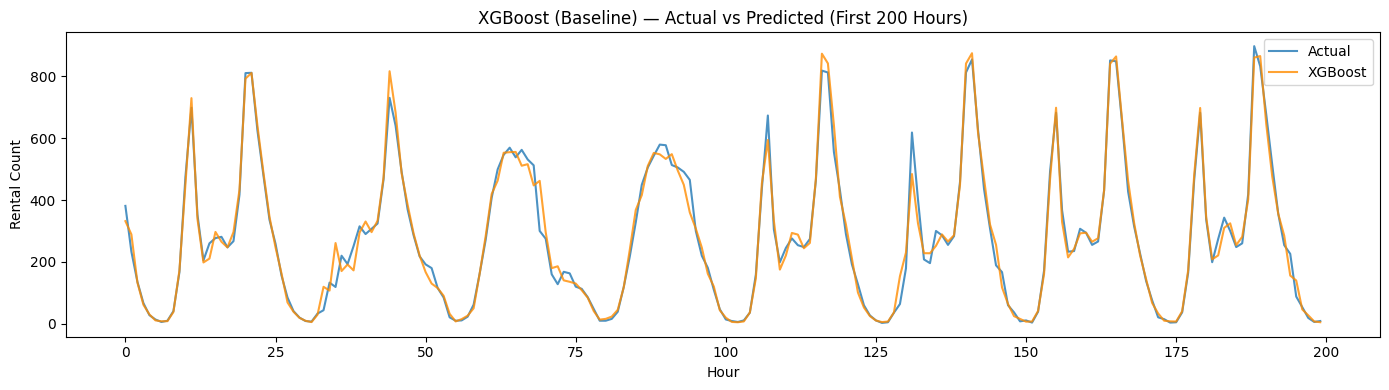

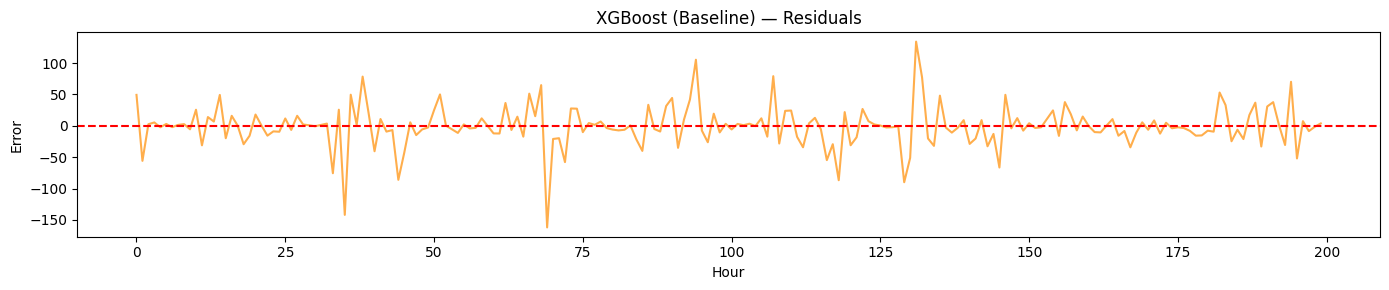

In [39]:
# --- XGBoost Baseline Plot ---
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:200], label="Actual", alpha=0.8)
plt.plot(pred_xgb[:200], label="XGBoost", alpha=0.8, color="darkorange")
plt.title("XGBoost (Baseline) — Actual vs Predicted (First 200 Hours)")
plt.xlabel("Hour")
plt.ylabel("Rental Count")
plt.legend()
plt.tight_layout()
plt.show()

# Residuals
residuals_xgb = y_test.values - pred_xgb
plt.figure(figsize=(14, 3))
plt.plot(residuals_xgb[:200], color="darkorange", alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.title("XGBoost (Baseline) — Residuals")
plt.xlabel("Hour")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

## 8. Time-Series Diagnostics (for SARIMAX)
Before fitting SARIMAX, we check two things:
1. **Stationarity** via the Augmented Dickey-Fuller (ADF) test — SARIMAX assumes the series is stationary
2. **ACF/PACF plots** — used to guide the choice of AR order `p` and MA order `q`

In [40]:
adf_result = adfuller(y_train)
print(f'ADF Statistic : {adf_result[0]:.4f}')
print(f'p-value       : {adf_result[1]:.6f}')
print('Conclusion    :', 'Stationary ✓' if adf_result[1] < 0.05 else 'Non-stationary — consider differencing')

ADF Statistic : -6.3029
p-value       : 0.000000
Conclusion    : Stationary ✓


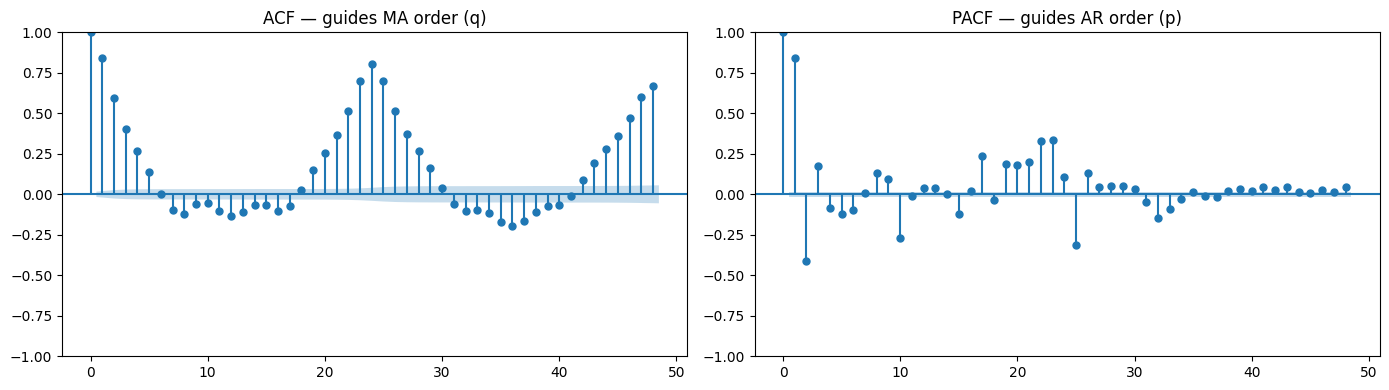

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_train, lags=48, ax=axes[0])   # MA order (q)
axes[0].set_title('ACF — guides MA order (q)')
plot_pacf(y_train, lags=48, ax=axes[1])  # AR order (p)
axes[1].set_title('PACF — guides AR order (p)')
plt.tight_layout()
plt.show()

## 9. SARIMAX — Baseline

A SARIMAX(1,0,1)(1,0,1)[24] model is fitted using cyclical and weather exogenous regressors.*italicized text*

In [42]:
# SARIMAX

sar_df = Bike.copy()

# Remove leakage
sar_df = sar_df.drop(columns=["casual", "registered", "instant"], errors="ignore")

# Cyclical encoding
sar_df["hr_sin"] = np.sin(2 * np.pi * sar_df["hr"] / 24)
sar_df["hr_cos"] = np.cos(2 * np.pi * sar_df["hr"] / 24)

sar_df["mnth_sin"] = np.sin(2 * np.pi * sar_df["mnth"] / 12)
sar_df["mnth_cos"] = np.cos(2 * np.pi * sar_df["mnth"] / 12)

# One-hot encoding
sar_df = pd.get_dummies(sar_df, columns=["season", "weathersit", "weekday"], drop_first=True)

# Sort by time
sar_df = sar_df.sort_values(["dteday", "hr"]).reset_index(drop=True)

# 80-20 split
split_index = int(len(sar_df) * 0.8)

train = sar_df.iloc[:split_index]
test  = sar_df.iloc[split_index:]

X_train = train.drop(columns=["cnt", "dteday"]).astype(float)
y_train = train["cnt"].astype(float)

X_test = test.drop(columns=["cnt", "dteday"]).astype(float)
y_test = test["cnt"].astype(float)

# Add constant
X_train_sm = sm.add_constant(X_train, has_constant="add")
X_test_sm  = sm.add_constant(X_test, has_constant="add")

X_test_sm = X_test_sm.reindex(columns=X_train_sm.columns, fill_value=0)

model = sm.tsa.statespace.SARIMAX(
    y_train,
    exog=X_train_sm,
    order=(1,0,1),
    seasonal_order=(1,0,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit = model.fit(disp=False)

forecast = fit.get_forecast(steps=len(y_test), exog=X_test_sm)
pred_sarimax = forecast.predicted_mean

rmse = np.sqrt(mean_squared_error(y_test, pred_sarimax))
mae  = mean_absolute_error(y_test, pred_sarimax)
r2   = r2_score(y_test, pred_sarimax)
mape = np.mean(np.abs((y_test - pred_sarimax) / np.maximum(y_test, 1))) * 100

print("SARIMAX (80-20)")
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)
print("MAPE:", mape)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX (80-20)
RMSE: 157.97399710766388
MAE : 119.6768753906292
R2  : 0.48664968064488934
MAPE: 311.4794653471363


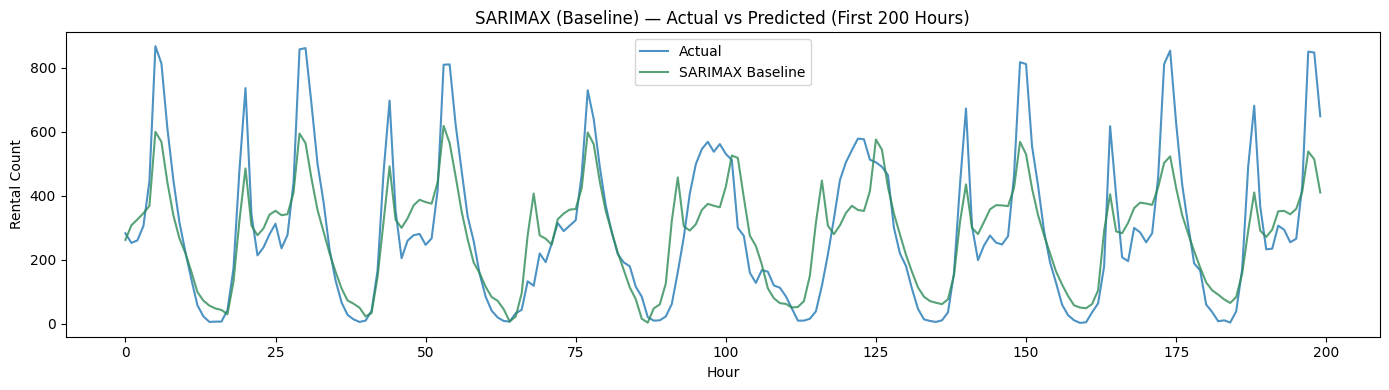

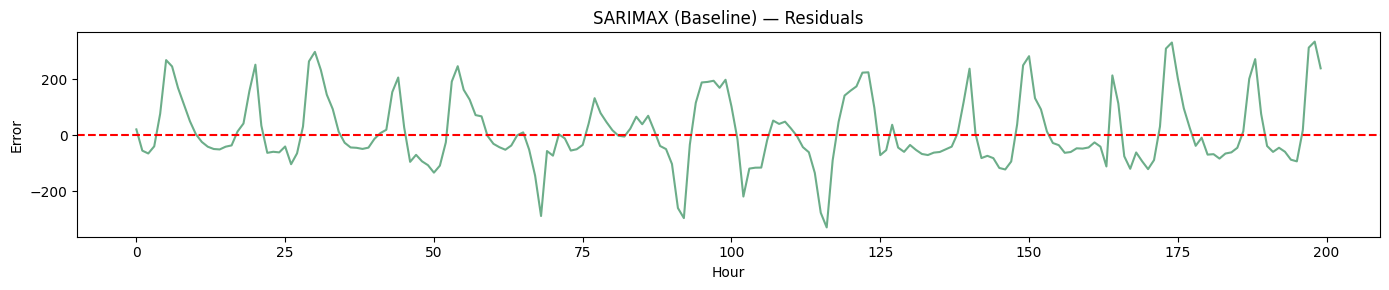

In [44]:
# --- SARIMAX Baseline Plot ---
pred_sar_plot = pred_sarimax.reset_index(drop=True)
y_test_sar_plot = y_test.reset_index(drop=True)

plt.figure(figsize=(14, 4))
plt.plot(y_test_sar_plot.values[:200], label="Actual", alpha=0.8)
plt.plot(pred_sar_plot.values[:200], label="SARIMAX Baseline", alpha=0.8, color="seagreen")
plt.title("SARIMAX (Baseline) — Actual vs Predicted (First 200 Hours)")
plt.xlabel("Hour")
plt.ylabel("Rental Count")
plt.legend()
plt.tight_layout()
plt.show()

# Residuals
residuals_sar = y_test_sar_plot.values - pred_sar_plot.values
plt.figure(figsize=(14, 3))
plt.plot(residuals_sar[:200], color="seagreen", alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.title("SARIMAX (Baseline) — Residuals")
plt.xlabel("Hour")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

## 10. Hyperparameter Tuning

### 10.1 · Random Forest — Tuned
`RandomizedSearchCV` with `TimeSeriesSplit(n_splits=5)` is used to respect the temporal ordering of the data.

In [45]:
# RANDOM FOREST TUNING


rf_df = Bike.copy()

rf_df = rf_df.drop(columns=["casual", "registered", "instant"], errors="ignore")

rf_df["hr_sin"] = np.sin(2 * np.pi * rf_df["hr"] / 24)
rf_df["hr_cos"] = np.cos(2 * np.pi * rf_df["hr"] / 24)
rf_df["mnth_sin"] = np.sin(2 * np.pi * rf_df["mnth"] / 12)
rf_df["mnth_cos"] = np.cos(2 * np.pi * rf_df["mnth"] / 12)

rf_df = pd.get_dummies(rf_df, columns=["season", "weathersit", "weekday"], drop_first=True)

rf_df = rf_df.sort_values(["dteday", "hr"]).reset_index(drop=True)

split_index = int(len(rf_df) * 0.8)
train = rf_df.iloc[:split_index]
test  = rf_df.iloc[split_index:]

X_train = train.drop(columns=["cnt", "dteday"])
y_train = train["cnt"]

X_test = test.drop(columns=["cnt", "dteday"])
y_test = test["cnt"]

tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 15, 20, 25, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
pred_rf_tuned = best_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_rf_tuned))
mae  = mean_absolute_error(y_test, pred_rf_tuned)
r2   = r2_score(y_test, pred_rf_tuned)
mape = np.mean(np.abs((y_test - pred_rf_tuned) / np.maximum(y_test, 1))) * 100

print("Best RF Params:", rf_search.best_params_)
print("Tuned Random Forest Results")
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)
print("MAPE:", mape)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 25}
Tuned Random Forest Results
RMSE: 80.66840195217172
MAE : 53.511763552791024
R2  : 0.8661403978494862
MAPE: 35.413360001157805


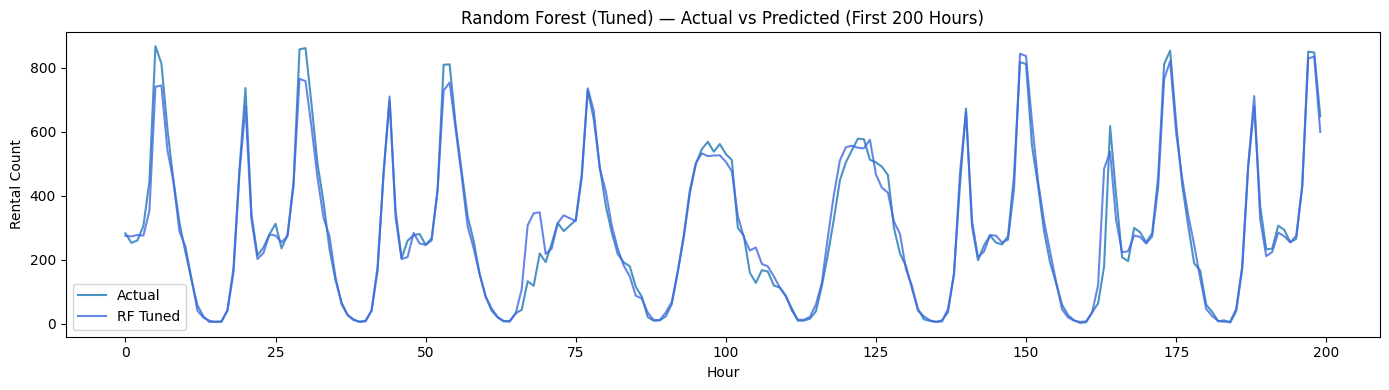

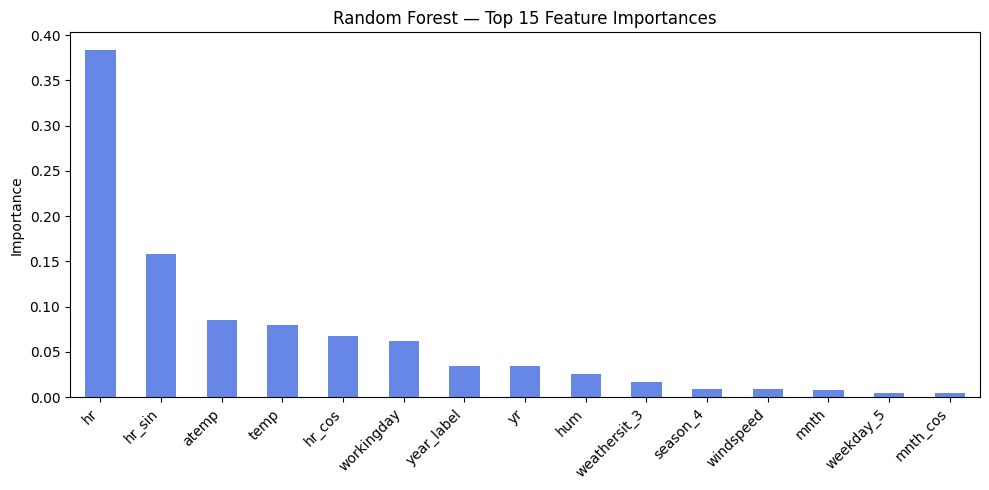

In [46]:
# --- Random Forest Tuned Plot ---
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:200], label="Actual", alpha=0.8)
plt.plot(pred_rf_tuned[:200], label="RF Tuned", alpha=0.8, color="royalblue")
plt.title("Random Forest (Tuned) — Actual vs Predicted (First 200 Hours)")
plt.xlabel("Hour")
plt.ylabel("Rental Count")
plt.legend()
plt.tight_layout()
plt.show()

# Feature Importance
feat_imp = pd.Series(
    rf_search.best_estimator_.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)[:15]

plt.figure(figsize=(10, 5))
feat_imp.plot(kind="bar", color="royalblue", alpha=0.8)
plt.title("Random Forest — Top 15 Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 10.2 · XGBoost — Tuned

In [47]:
# XGBOOST TUNING


xgb_df = Bike.copy()

xgb_df["datetime"] = pd.to_datetime(xgb_df["dteday"]) + pd.to_timedelta(xgb_df["hr"], unit="h")
xgb_df = xgb_df.sort_values("datetime").reset_index(drop=True)

xgb_df = xgb_df.drop(columns=["casual", "registered", "instant", "year_label"], errors="ignore")

xgb_df["lag_1"] = xgb_df["cnt"].shift(1)
xgb_df["lag_24"] = xgb_df["cnt"].shift(24)
xgb_df["lag_168"] = xgb_df["cnt"].shift(168)

xgb_df = xgb_df.dropna().reset_index(drop=True)

xgb_df["hr_sin"] = np.sin(2 * np.pi * xgb_df["hr"] / 24)
xgb_df["hr_cos"] = np.cos(2 * np.pi * xgb_df["hr"] / 24)

xgb_df = pd.get_dummies(xgb_df, columns=["season", "weathersit", "weekday"], drop_first=True)

split_index = int(len(xgb_df) * 0.8)
train = xgb_df.iloc[:split_index]
test  = xgb_df.iloc[split_index:]

X_train = train.drop(columns=["cnt", "dteday", "datetime"])
y_train = train["cnt"]

X_test = test.drop(columns=["cnt", "dteday", "datetime"])
y_test = test["cnt"]

tscv = TimeSeriesSplit(n_splits=5)

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_param_grid = {
    "n_estimators": [200, 400, 600, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 5, 7, 9],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "reg_alpha": [0, 0.01, 0.1],
    "reg_lambda": [1, 1.5, 2]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,
    n_iter=25,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
pred_xgb_tuned = best_xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_xgb_tuned))
mae  = mean_absolute_error(y_test, pred_xgb_tuned)
r2   = r2_score(y_test, pred_xgb_tuned)
mape = np.mean(np.abs((y_test - pred_xgb_tuned) / np.maximum(y_test, 1))) * 100

print("Best XGB Params:", xgb_search.best_params_)
print("Tuned XGBoost Results")
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)
print("MAPE:", mape)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best XGB Params: {'subsample': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 0.01, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}
Tuned XGBoost Results
RMSE: 46.13202595116949
MAE : 29.838071823120117
R2  : 0.9559618830680847
MAPE: 29.38074089143703


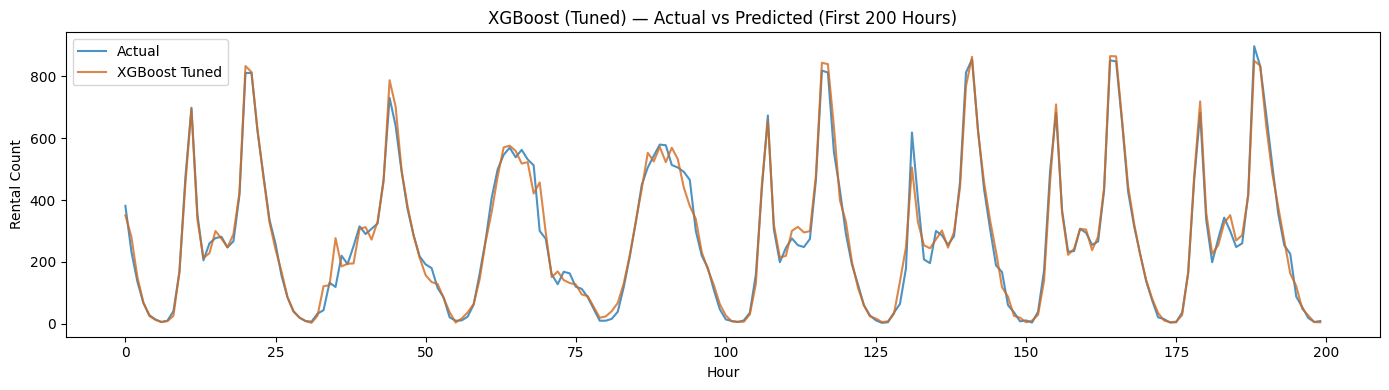

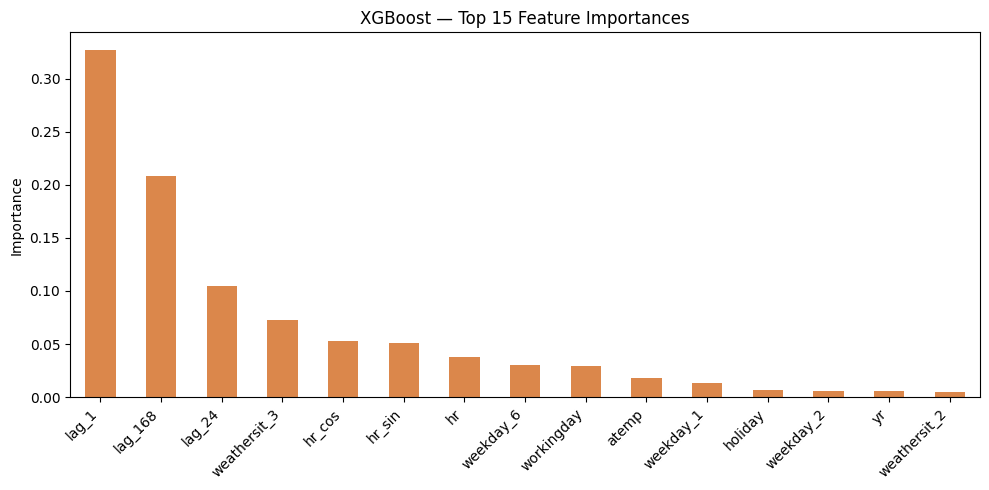

In [48]:
# --- XGBoost Tuned Plot ---
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:200], label="Actual", alpha=0.8)
plt.plot(pred_xgb_tuned[:200], label="XGBoost Tuned", alpha=0.8, color="chocolate")
plt.title("XGBoost (Tuned) — Actual vs Predicted (First 200 Hours)")
plt.xlabel("Hour")
plt.ylabel("Rental Count")
plt.legend()
plt.tight_layout()
plt.show()

# Feature Importance
xgb_imp = pd.Series(
    xgb_search.best_estimator_.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)[:15]

plt.figure(figsize=(10, 5))
xgb_imp.plot(kind="bar", color="chocolate", alpha=0.8)
plt.title("XGBoost — Top 15 Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 10.3 · SARIMAX — Tuned (auto_arima)
`auto_arima` is run on the last 3,000 training rows for speed, then the best order is refitted on the full training set.

In [52]:
from pmdarima             import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define the missing metrics_banner function
def metrics_banner(model_name, rmse, mae, r2, mape):
    print(f"\n=== {model_name} Results ===")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R2   : {r2:.4f}")
    print(f"MAPE : {mape:.4f}%")

EXOG_COLS = ["hr_sin", "hr_cos", "mnth_sin", "mnth_cos",
             "temp", "hum", "windspeed", "workingday", "weathersit"]

sar_tune = Bike.copy()
sar_tune = sar_tune.drop(columns=["casual", "registered", "instant", "year_label"], errors="ignore")
sar_tune["hr_sin"]   = np.sin(2 * np.pi * sar_tune["hr"]   / 24)
sar_tune["hr_cos"]   = np.cos(2 * np.pi * sar_tune["hr"]   / 24)
sar_tune["mnth_sin"] = np.sin(2 * np.pi * sar_tune["mnth"] / 12)
sar_tune["mnth_cos"] = np.cos(2 * np.pi * sar_tune["mnth"] / 12)
sar_tune = sar_tune.sort_values(["dteday", "hr"]).reset_index(drop=True)

split_idx    = int(len(sar_tune) * 0.8)
train_st     = sar_tune.iloc[:split_idx]
test_st      = sar_tune.iloc[split_idx:]
X_tr_st      = train_st[EXOG_COLS].astype(float)
y_tr_st      = train_st["cnt"].astype(float)
X_te_st      = test_st[EXOG_COLS].astype(float)
y_te_st      = test_st["cnt"].astype(float)

# ── auto_arima on last 3000 rows (speed) ──────────────────────────────────────
TUNE_SIZE = 3000
y_tune_s  = y_tr_st.iloc[-TUNE_SIZE:].reset_index(drop=True)
X_tune_s  = X_tr_st.iloc[-TUNE_SIZE:].reset_index(drop=True)

print("Running auto_arima stepwise search …")
auto_model = auto_arima(
    y_tune_s, X=X_tune_s,
    seasonal=True, m=24,
    stepwise=True, information_criterion="aic",
    d=0, D=0, max_p=2, max_q=2, max_P=1, max_Q=1,
    enforce_stationarity=False, enforce_invertibility=False,
    trace=True, error_action="ignore", suppress_warnings=True
)
print(f"\n✅ Best order : {auto_model.order}   Seasonal: {auto_model.seasonal_order}")

# ── Refit on full training data ────────────────────────────────────────────────
print("\nRefitting on full training set …")
best_sar = SARIMAX(
    y_tr_st,
    exog=X_tr_st,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# ── Forecast ──────────────────────────────────────────────────────────────────
best_pred_sar = best_sar.predict(
    start=len(y_tr_st), end=len(y_tr_st) + len(y_te_st) - 1,
    exog=X_te_st
).reset_index(drop=True)
y_test_plot = y_te_st.reset_index(drop=True)

sar_t_rmse = np.sqrt(mean_squared_error(y_test_plot, best_pred_sar))
sar_t_mae  = mean_absolute_error(y_test_plot, best_pred_sar)
sar_t_r2   = r2_score(y_test_plot, best_pred_sar)
sar_t_mape = np.mean(np.abs((y_test_plot - best_pred_sar) / y_test_plot)) * 100

metrics_banner("SARIMAX — Tuned (auto_arima)", sar_t_rmse, sar_t_mae, sar_t_r2, sar_t_mape)
print(f"  AIC  : {best_sar.aic:.2f}")

Running auto_arima stepwise search …
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[24] intercept   : AIC=34784.347, Time=58.37 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=38734.571, Time=2.36 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=35103.561, Time=42.03 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=35594.780, Time=30.63 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=38851.079, Time=1.01 sec
 ARIMA(2,0,2)(0,0,1)[24] intercept   : AIC=35025.902, Time=42.25 sec
 ARIMA(2,0,2)(1,0,0)[24] intercept   : AIC=34703.593, Time=50.52 sec
 ARIMA(2,0,2)(0,0,0)[24] intercept   : AIC=36008.581, Time=7.72 sec
 ARIMA(1,0,2)(1,0,0)[24] intercept   : AIC=34692.387, Time=43.00 sec
 ARIMA(1,0,2)(0,0,0)[24] intercept   : AIC=36078.243, Time=6.49 sec
 ARIMA(1,0,2)(1,0,1)[24] intercept   : AIC=inf, Time=64.01 sec
 ARIMA(1,0,2)(0,0,1)[24] intercept   : AIC=35019.340, Time=42.76 sec
 ARIMA(0,0,2)(1,0,0)[24] intercept   : AIC=34778.388, Time=28.67 sec
 ARIMA(1,0,1)(1,0,0)[24] intercep

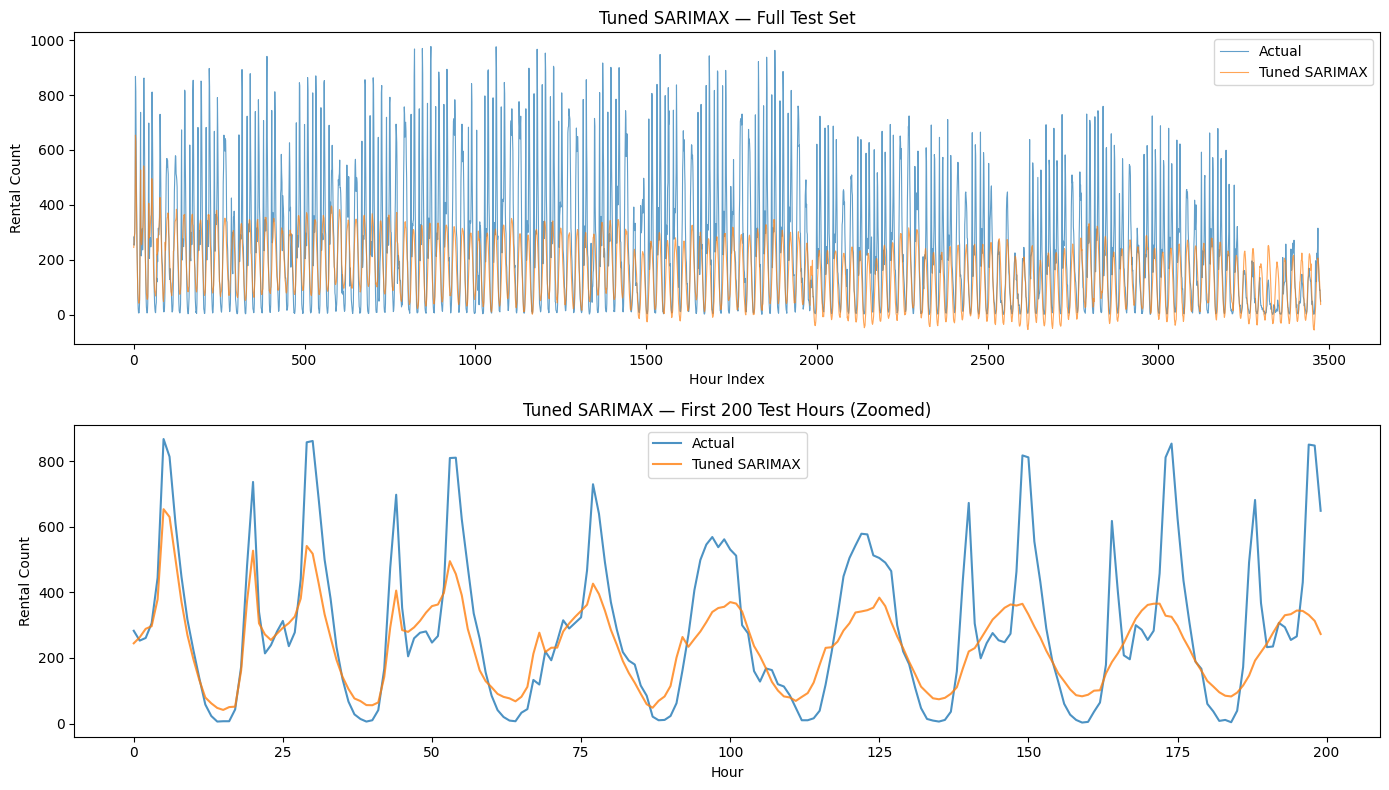

In [53]:
# --- 6. PLOT ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full test set
axes[0].plot(y_test_plot.values, label="Actual", alpha=0.7, linewidth=0.8)
axes[0].plot(best_pred_sar.values, label="Tuned SARIMAX", alpha=0.7, linewidth=0.8)
axes[0].set_title("Tuned SARIMAX — Full Test Set")
axes[0].set_xlabel("Hour Index")
axes[0].set_ylabel("Rental Count")
axes[0].legend()

# First 200 hours (zoomed)
axes[1].plot(y_test_plot.values[:200], label="Actual", alpha=0.8)
axes[1].plot(best_pred_sar.values[:200], label="Tuned SARIMAX", alpha=0.8)
axes[1].set_title("Tuned SARIMAX — First 200 Test Hours (Zoomed)")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Rental Count")
axes[1].legend()

plt.tight_layout()
plt.show()